# AEGIS Performance Summary

This notebook exposes the `performance_summary` plotting code directly so you can modify layout, legend placement, and styling without editing the script first.

Edit the configuration cell, then run the notebook top to bottom.


In [37]:
from pathlib import Path
import json
from IPython.display import display

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'figures' else Path.cwd().resolve()
FIG_DIR = ROOT / 'figures'
RESULT_DIR = ROOT / 'results' / 'sc26_run_20260404T204625Z'
PERF_ARTIFACT = None  # Optional override for simulated_performance.json

PLOT_CONFIG = {
    'figsize': (25.8, 5.6),
    'width_ratios': [1.45, 1.45, 1.1, 1.1, 1.15],
    'panel_a_legend': {
        'loc': 'upper left',
        'bbox_to_anchor': (0.03, 0.98),
        'ncol': 1,
        'fontsize': 10.4,
        'handlelength': 1.4,
        'columnspacing': 0.8,
        'borderaxespad': 0.0,
    },
    'panel_b_legend': {
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0.98),
        'ncol': 1,
        'fontsize': 10.4,
        'handlelength': 1.6,
        'columnspacing': 0.8,
        'borderaxespad': 0.0,
    },
}

plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 360,
    'font.family': 'DejaVu Sans',
    'font.size': 13.5,
    'axes.titlesize': 16,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.14,
    'grid.linewidth': 0.7,
    'xtick.labelsize': 12.5,
    'ytick.labelsize': 12.5,
    'legend.fontsize': 12.5,
    'axes.axisbelow': True,
    'legend.frameon': False,
})

PALETTE = {
    'blue': '#2f5d8a',
    'green': '#4c956c',
    'amber': '#d9911f',
    'red': '#c8553d',
}


In [38]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))


def collect_microbenchmarks(result_dir: Path):
    items = []
    for path in sorted(result_dir.glob('bpf_microbenchmark_*.json')):
        payload = load_json(path)
        overhead = payload['overhead']
        throughput_loss = overhead.get('throughput_loss_pct', abs(overhead['ops_per_sec_pct']))
        items.append({
            'mode': payload['config']['mode'],
            'elapsed_pct': overhead['elapsed_pct'],
            'task_clock_pct': overhead['task_clock_pct'],
            'throughput_loss_pct': throughput_loss,
        })
    mode_order = {'openat': 0, 'read': 1, 'connect': 2, 'execve': 3}
    items.sort(key=lambda row: mode_order.get(row['mode'], 99))
    return items


def resolve_perf_artifact(result_dir: Path):
    if PERF_ARTIFACT:
        return Path(PERF_ARTIFACT)
    local = result_dir / 'simulated_performance.json'
    if local.exists():
        return local
    standalone = sorted((ROOT / 'results').glob('simulated_performance_*.json'))
    return standalone[-1] if standalone else None


def save_fig(fig, stem: str):
    png_path = FIG_DIR / f'{stem}.png'
    pdf_path = FIG_DIR / f'{stem}.pdf'
    fig.savefig(png_path, bbox_inches='tight', facecolor='white')
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    print(f'Saved {png_path.relative_to(ROOT)} and {pdf_path.relative_to(ROOT)}')


In [39]:
microbench = collect_microbenchmarks(RESULT_DIR)
real_latency_sweep = load_json(RESULT_DIR / 'real_latency_sweep.json')
perf_artifact = resolve_perf_artifact(RESULT_DIR)
scaling_payload = load_json(perf_artifact) if perf_artifact else None

print('Using result dir:', RESULT_DIR.relative_to(ROOT))
print('Using scaling artifact:', perf_artifact.relative_to(ROOT) if perf_artifact else 'None')
print('Microbench modes:', [row['mode'] for row in microbench])
print('Intervals:', [row['interval'] for row in real_latency_sweep['summary']])
if scaling_payload:
    print('Scaling panels available:', list(scaling_payload.keys()))


Using result dir: results/sc26_run_20260404T204625Z
Using scaling artifact: results/simulated_performance_20260406T055526Z.json
Microbench modes: ['openat', 'read', 'connect']
Intervals: [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
Scaling panels available: ['created_at', 'experiment', 'interval_sweep', 'agent_count_sweep', 'workload_type_sweep', 'all_results', 'low_overhead_count', 'total_configurations']


In [40]:
def draw_scaling_sweep(axes, payload):
    interval_sweep = sorted(payload['interval_sweep'], key=lambda row: row['attestation_interval'])
    agent_sweep = sorted(payload['agent_count_sweep'], key=lambda row: row['agent_count'])
    workload_sweep = payload['workload_type_sweep']

    axes[0].plot(
        [row['attestation_interval'] for row in interval_sweep],
        [row['overhead_percent'] for row in interval_sweep],
        marker='o', linewidth=2.5, markersize=7, color=PALETTE['blue'],
    )
    axes[0].set_xscale('log')
    axes[0].set_xlabel('Attestation interval (s)')
    axes[0].set_ylabel('Overhead (%)')

    axes[1].plot(
        [row['agent_count'] for row in agent_sweep],
        [row['overhead_percent'] for row in agent_sweep],
        marker='o', linewidth=2.5, markersize=7, color=PALETTE['green'],
    )
    axes[1].set_xlabel('Agent count')
    axes[1].set_ylabel('Overhead (%)')

    workload_labels = [row['workload_type'].replace('_', '-').title() for row in workload_sweep]
    workload_values = [row['overhead_percent'] for row in workload_sweep]
    workload_colors = [PALETTE['blue'], PALETTE['green'], PALETTE['amber'], PALETTE['red']][: len(workload_sweep)]
    bars = axes[2].bar(workload_labels, workload_values, color=workload_colors)
    axes[2].set_ylabel('Overhead (%)')
    axes[2].tick_params(axis='x', rotation=15)
    axes[2].set_ylim(0, max(workload_values) * 1.18)
    for bar, value in zip(bars, workload_values):
        axes[2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.08,
            f'{value:.2f}%',
            ha='center', va='bottom', fontsize=11.0, fontweight='semibold',
        )


def draw_performance_overhead(ax_bar, ax_line, microbench, sweep_payload, config):
    sweep_summary = sorted(sweep_payload['summary'], key=lambda row: row['interval'])
    intervals = [row['interval'] for row in sweep_summary]
    latencies = [row['avg_latency_ms'] for row in sweep_summary]
    cpu_pct = [row['cpu_overhead'] for row in sweep_summary]

    mode_names = [row['mode'] for row in microbench]
    elapsed_pct = [row['elapsed_pct'] for row in microbench]
    task_clock_pct = [row['task_clock_pct'] for row in microbench]
    throughput_loss = [row['throughput_loss_pct'] for row in microbench]
    xpos = np.arange(len(mode_names))
    width = 0.24

    bars_elapsed = ax_bar.bar(xpos - width, elapsed_pct, width=width, label='Elapsed overhead', color=PALETTE['blue'])
    bars_task = ax_bar.bar(xpos, task_clock_pct, width=width, label='Task-clock overhead', color=PALETTE['green'])
    bars_throughput = ax_bar.bar(xpos + width, throughput_loss, width=width, label='Throughput loss', color=PALETTE['amber'])
    ax_bar.set_xticks(xpos)
    ax_bar.set_xticklabels(mode_names)
    ax_bar.set_ylabel('Percent')
    ax_bar.set_ylim(0, max(max(elapsed_pct), max(task_clock_pct), max(throughput_loss)) * 1.24)
    ax_bar.legend(**config['panel_a_legend'])
    for bars, values in [
        (bars_elapsed, elapsed_pct),
        (bars_task, task_clock_pct),
        (bars_throughput, throughput_loss),
    ]:
        for bar, value in zip(bars, values):
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.45,
                f'{value:.1f}%',
                ha='center', va='bottom', fontsize=9.2, fontweight='semibold', color='#111111',
            )

    ax_line.plot(intervals, latencies, marker='o', markersize=7, linewidth=2.5, color=PALETTE['red'], label='Detection latency (ms)')
    ax_line.set_xscale('log')
    ax_line.set_xlabel('Attestation interval (s)')
    ax_line.set_ylabel('Detection latency (ms)', color=PALETTE['red'])
    ax_line.tick_params(axis='y', labelcolor=PALETTE['red'])
    ax_line.grid(axis='both', alpha=0.16)

    ax_line_cpu = ax_line.twinx()
    ax_line_cpu.plot(intervals, cpu_pct, marker='s', markersize=6, linestyle='--', linewidth=2.2, color=PALETTE['green'], label='CPU overhead (%)')
    ax_line_cpu.set_ylabel('CPU overhead (%)', color=PALETTE['green'])
    ax_line_cpu.tick_params(axis='y', labelcolor=PALETTE['green'])

    highlight_indices = [0, 2, len(intervals) - 1]
    for idx in highlight_indices:
        ax_line.annotate(
            f'{latencies[idx]:.0f} ms',
            (intervals[idx], latencies[idx]),
            textcoords='offset points', xytext=(0, 9), ha='center',
            fontsize=10.5, fontweight='semibold', color=PALETTE['red'],
        )
        ax_line_cpu.annotate(
            f'{cpu_pct[idx]:.3f}%',
            (intervals[idx], cpu_pct[idx]),
            textcoords='offset points', xytext=(0, -18), ha='center',
            fontsize=10.5, fontweight='semibold', color=PALETTE['green'],
            bbox={'boxstyle': 'round,pad=0.18', 'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.9},
        )

    lines = ax_line.get_lines() + ax_line_cpu.get_lines()
    labels = [line.get_label() for line in lines]
    ax_line.legend(lines, labels, **config['panel_b_legend'])


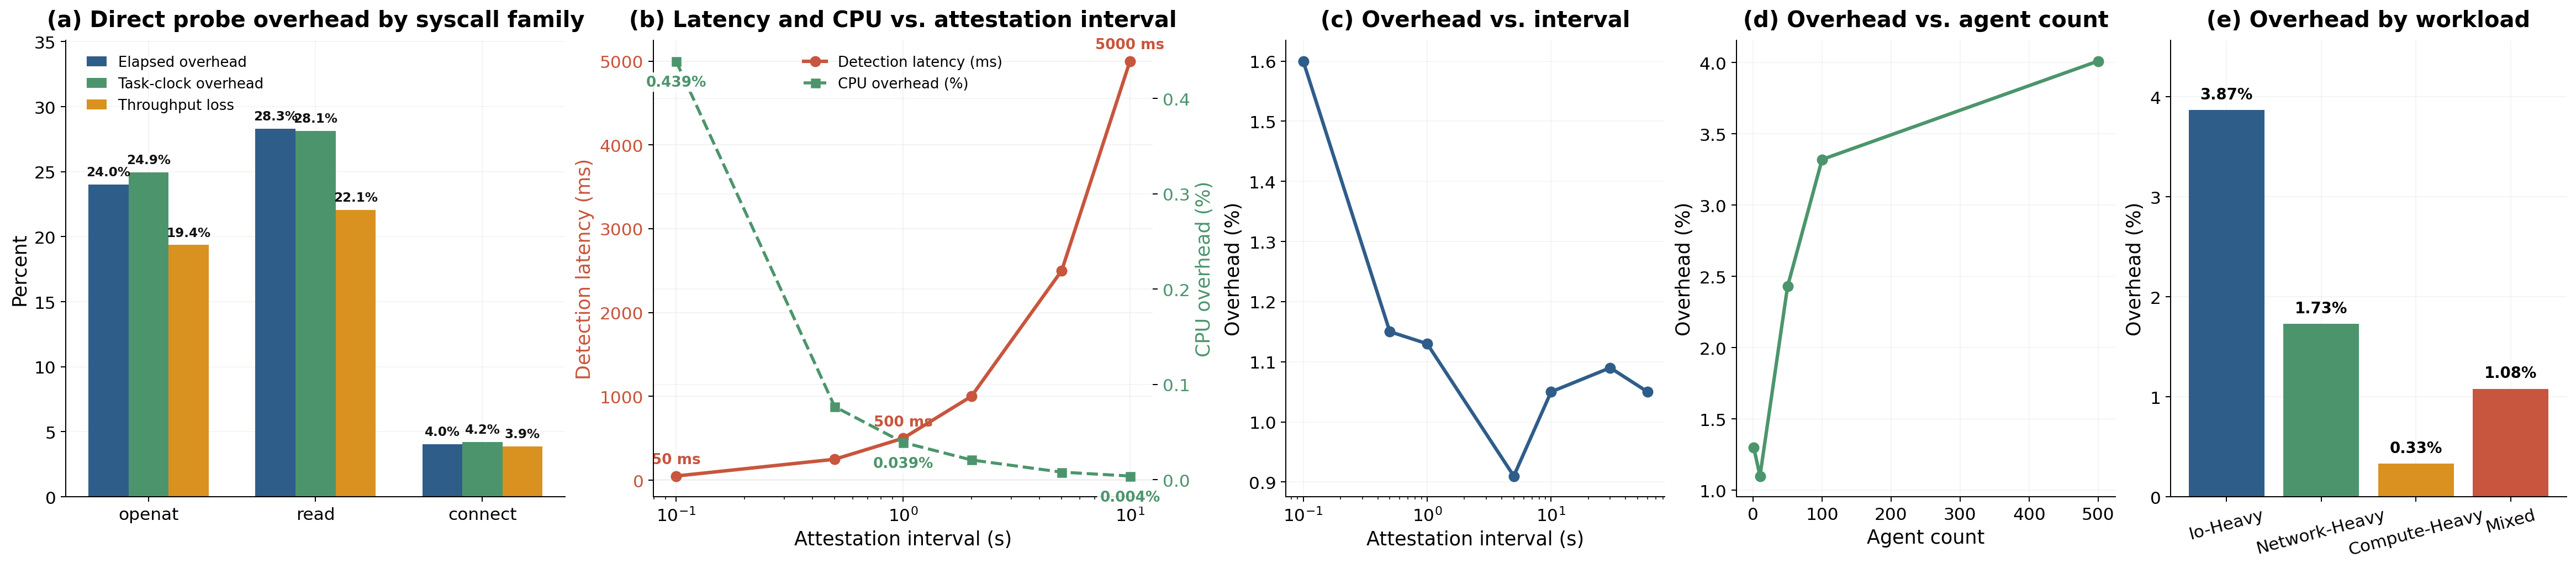

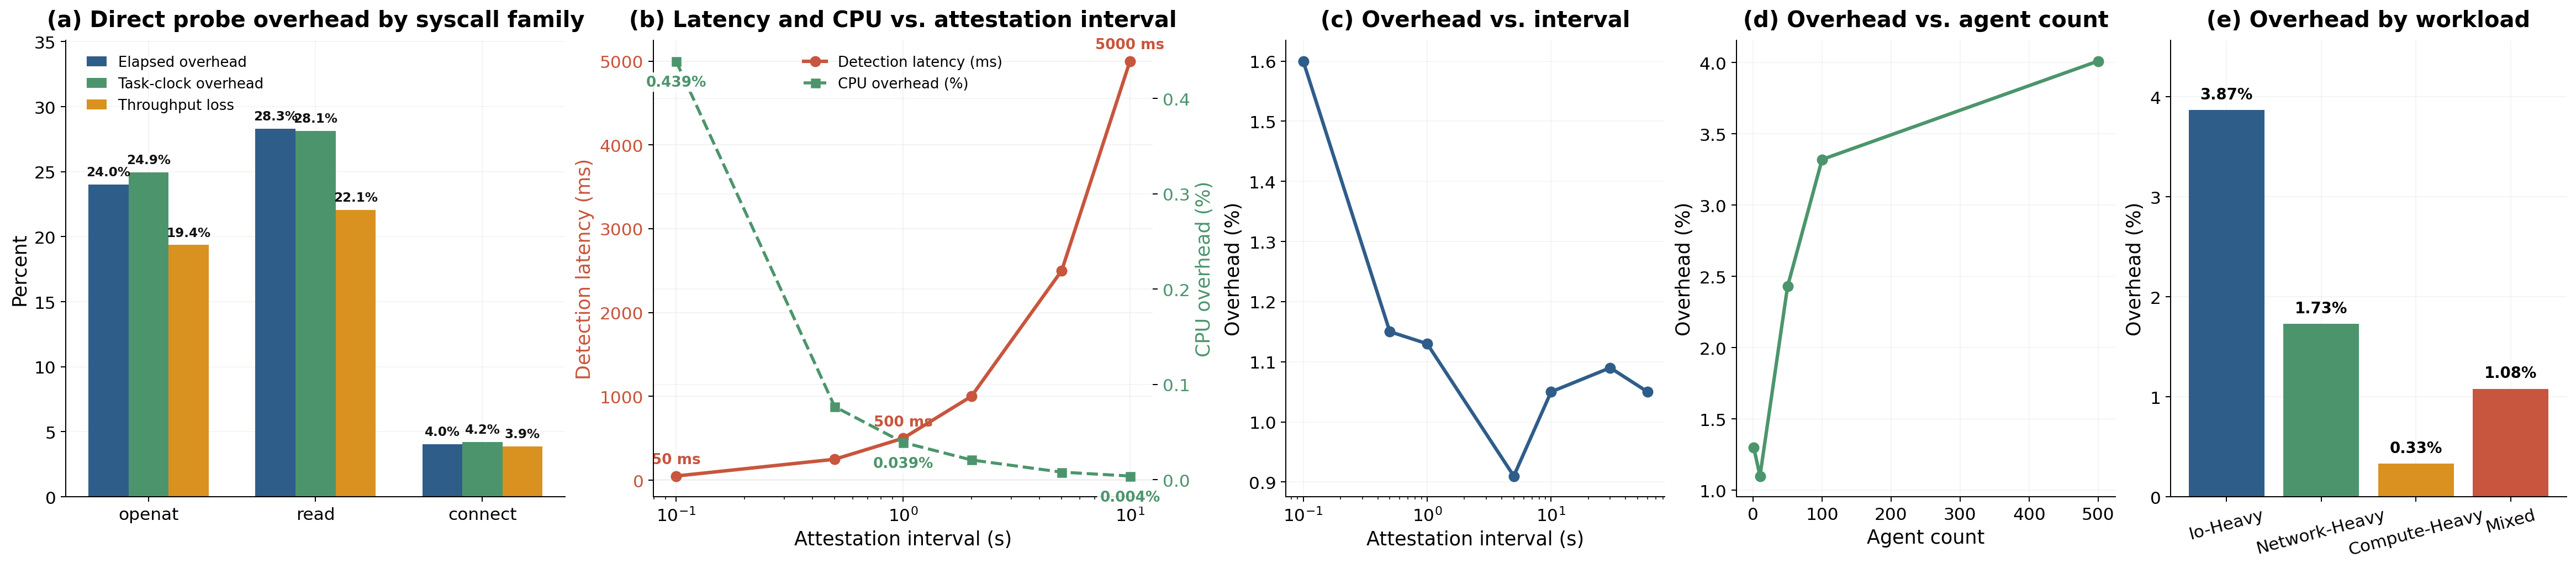

In [41]:
if scaling_payload is None:
    raise RuntimeError('No scaling artifact found. Set PERF_ARTIFACT or place simulated_performance_*.json under results/.')

fig, axes = plt.subplots(
    1,
    5,
    figsize=PLOT_CONFIG['figsize'],
    gridspec_kw={'width_ratios': PLOT_CONFIG['width_ratios']},
    constrained_layout=True,
)
ax_bar, ax_line, ax_scale_interval, ax_scale_agents, ax_scale_workload = axes

draw_performance_overhead(ax_bar, ax_line, microbench, real_latency_sweep, PLOT_CONFIG)
draw_scaling_sweep([ax_scale_interval, ax_scale_agents, ax_scale_workload], scaling_payload)

ax_bar.set_title('(a) Direct probe overhead by syscall family', pad=10)
ax_line.set_title('(b) Latency and CPU vs. attestation interval', pad=10)
ax_scale_interval.set_title('(c) Overhead vs. interval', pad=10)
ax_scale_agents.set_title('(d) Overhead vs. agent count', pad=10)
ax_scale_workload.set_title('(e) Overhead by workload', pad=10)

display(fig)
plt.show()


In [42]:
save_fig(fig, 'performance_summary')


Saved figures/performance_summary.png and figures/performance_summary.pdf
